Processing frames 0 to 7200 (time 0s to 120s)
Processing video 1: Cam1_sync.mp4


Video 1: 100%|██████████| 7200/7200 [00:33<00:00, 216.53it/s]


Processing video 2: Cam2_sync.mp4


Video 2: 100%|██████████| 7200/7200 [00:33<00:00, 214.34it/s]


Processing video 3: Cam3_sync.mp4


...

Processing video 6: GoPro3_sync.mp4


Video 6: 100%|█████████▉| 7193/7200 [02:09<00:00, 55.59it/s]


Processing video 7: GoPro4_sync.mp4


Video 7: 100%|██████████| 7200/7200 [02:08<00:00, 55.83it/s]



Time series lengths:
Video 1: 7200 frames
Video 2: 7200 frames
Video 3: 7200 frames
Video 4: 7193 frames
Video 5: 7193 frames
Video 6: 7193 frames
Video 7: 7200 frames

Detecting light events in each video:
Video 1: 7 peaks at frames [6086 6232 6302 6389 6455 6492 6530]
Video 2: 7 peaks at frames [6010 6158 6227 6315 6381 6417 6456]
Video 3: 7 peaks at frames [5937 6085 6156 6243 6310 6346 6384]
Video 4: 7 peaks at frames [4701 4851 4917 5007 5073 5109 5145]
Video 5: 7 peaks at frames [5306 5453 5523 5612 5678 5714 5750]
Video 6: 7 peaks at frames [3493 3638 3711 3794 3860 3896 3938]
Video 7: 7 peaks at frames [3963 4111 4186 4271 4336 4373 4414]

First peak positions before alignment:
  Video 1: 6086
  Video 2: 6010
  Video 3: 5937
  Video 4: 4701
  Video 5: 5306
  Video 6: 3493
  Video 7: 3963

Shifts applied to align all first peaks at t=0:
  Video 1: shift left by 2593 frames
  Video 2: shift left by 2517 frames
  Video 3: shift left by 2444 frames
  Video 4: shift left by 1208 fr

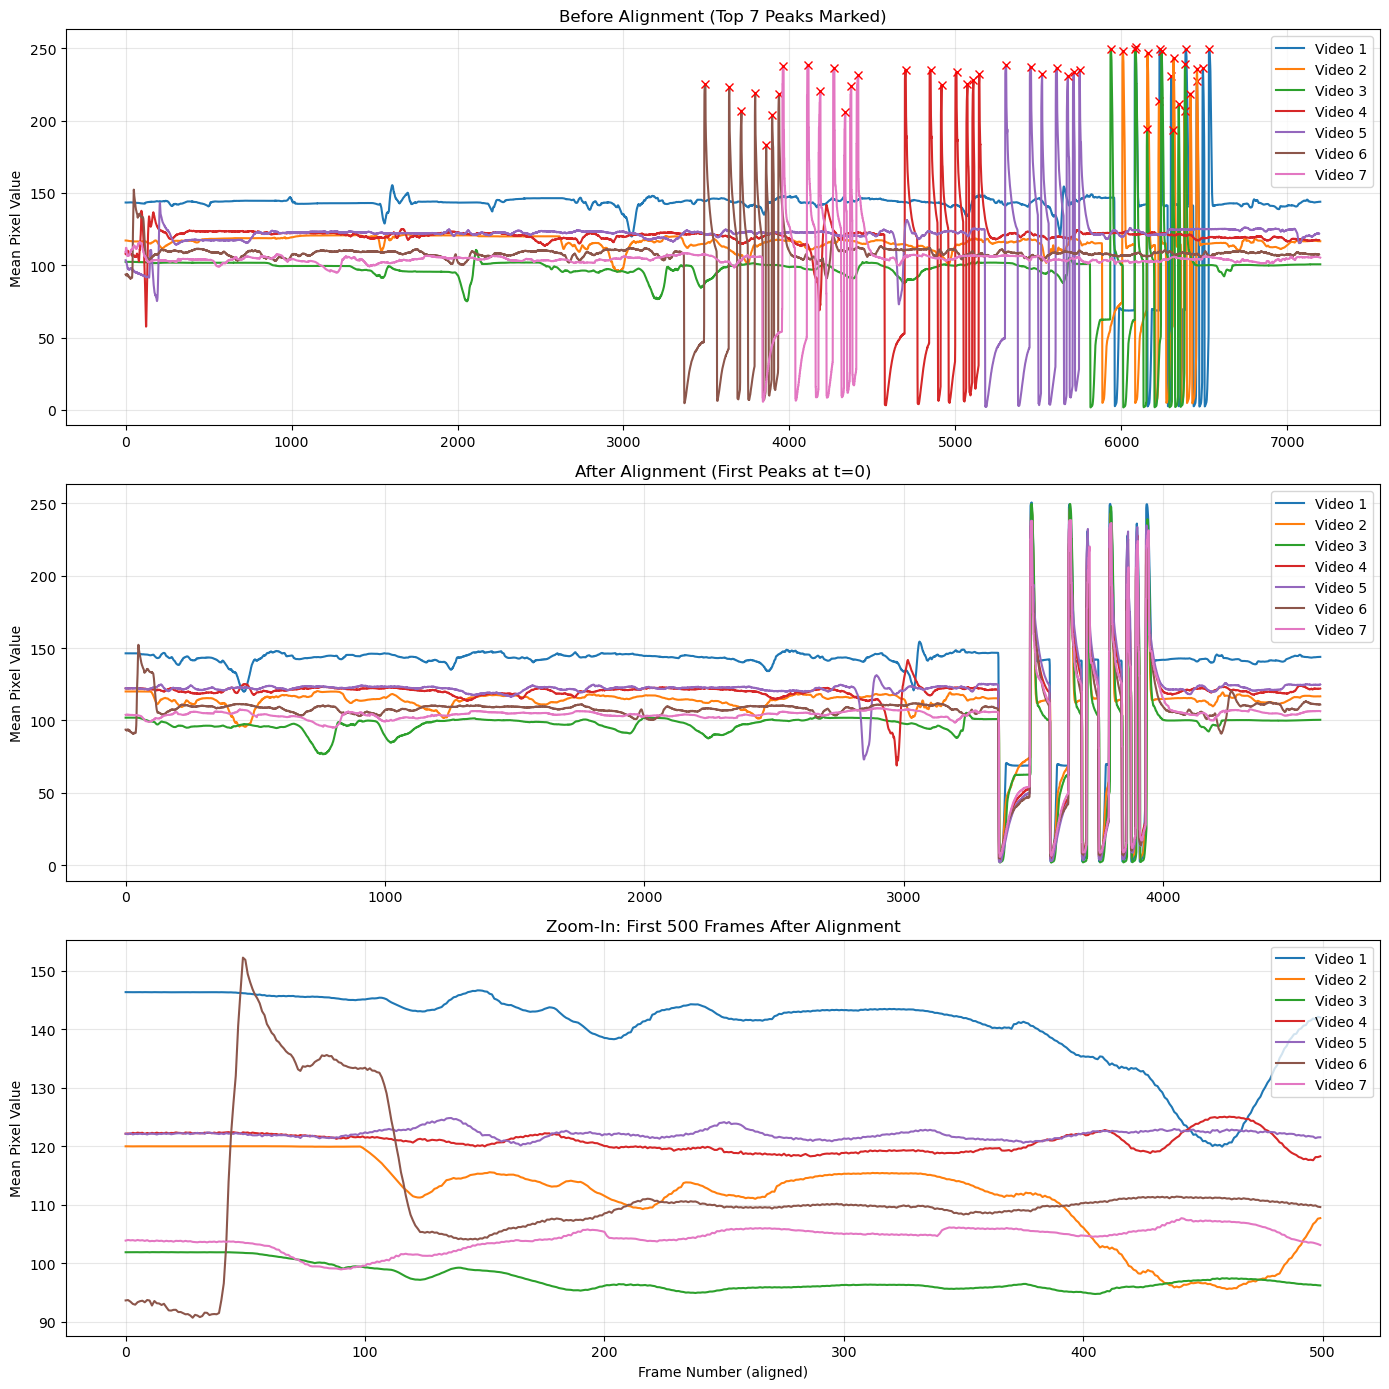

Camera shift values saved to /root/vast/eric/jernigan_folder_misc/Synchronization_2025-8-14/camera_shifts.npy


In [1]:
# Video synchronization using peak detection and alignment (top 7 flashes, fixed alignment)

import cv2
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

def extract_frame_means(video_paths, start_second=20, end_second=100, fps=60):
    """Extract mean pixel values from video segments for synchronization analysis."""
    start_frame = int(start_second * fps)
    end_frame = int(end_second * fps)
    print(f"Processing frames {start_frame} to {end_frame} (time {start_second}s to {end_second}s)")
    frame_means = []
    for i, path in enumerate(video_paths):
        print(f"Processing video {i+1}: {Path(path).name}")
        cap = cv2.VideoCapture(path)
        means = []
        if not cap.isOpened():
            print(f"Error: Couldn't open video {path}")
            continue
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        for _ in tqdm(range(end_frame - start_frame), desc=f"Video {i+1}"):
            ret, frame = cap.read()
            if not ret:
                break
            mean_value = np.mean(frame)
            means.append(mean_value)
        cap.release()
        frame_means.append(np.array(means))
    return frame_means

def detect_light_events(signal_data, distance=10, top_k=7):
    """Detect strongest light flash events in a time series using peak detection."""
    signal_mean = np.mean(signal_data)
    signal_range = np.max(signal_data) - np.min(signal_data)
    auto_prominence = max(20, signal_range * 0.15)

    peaks, props = find_peaks(
        signal_data,
        prominence=auto_prominence,
        distance=distance,
        height=signal_mean + auto_prominence * 0.4
    )

    if len(peaks) < top_k:
        peaks, props = find_peaks(
            signal_data,
            prominence=auto_prominence * 0.6,
            distance=distance,
            height=signal_mean + auto_prominence * 0.3
        )

    # Keep only the top_k strongest peaks (by peak height)
    if len(peaks) > top_k:
        sort_idx = np.argsort(props["peak_heights"])[::-1]
        peaks = peaks[sort_idx[:top_k]]

    return np.sort(peaks)

# --------------------------------------------------------------------
# NEW video paths
base_dir = "/root/vast/eric/jernigan_folder_misc/Synchronization_2025-8-14/"
video_paths = [
    f"{base_dir}Cam1_sync.mp4",
    f"{base_dir}Cam2_sync.mp4",
    f"{base_dir}Cam3_sync.mp4",
    f"{base_dir}GoPro1_sync.mp4",
    f"{base_dir}GoPro2_sync.mp4",
    f"{base_dir}GoPro3_sync.mp4",
    f"{base_dir}GoPro4_sync.mp4",
]

# Extract mean pixel values
frame_sums = extract_frame_means(video_paths, start_second=0, end_second=120, fps=60)

print("\nTime series lengths:")
for i, means in enumerate(frame_sums):
    print(f"Video {i+1}: {len(means)} frames")

# --- Detect peaks ---
print("\nDetecting light events in each video:")
all_peaks = []
for i, signal in enumerate(frame_sums):
    peaks = detect_light_events(signal, top_k=7)
    all_peaks.append(peaks)
    print(f"Video {i+1}: {len(peaks)} peaks at frames {peaks}")

# --- Align by first peak ---
reference_camera = 0
# Get first peak index for each video
first_peak_indices = [peaks[0] if len(peaks) > 0 else None for peaks in all_peaks]
if any(idx is None for idx in first_peak_indices):
    raise RuntimeError("Could not find first peak in all videos!")

print("\nFirst peak positions before alignment:")
for i, idx in enumerate(first_peak_indices):
    print(f"  Video {i+1}: {idx}")

# Compute shifts so all first peaks align to 0
min_first = min(first_peak_indices)  # earliest detected flash
shifts = [idx - min_first for idx in first_peak_indices]

print("\nShifts applied to align all first peaks at t=0:")
for i, s in enumerate(shifts):
    print(f"  Video {i+1}: shift left by {s} frames")

# Apply shifts
aligned_segments = []
for shift, signal in zip(shifts, frame_sums):
    if shift > 0:
        aligned = signal[shift:]               # drop frames before first peak
    else:
        aligned = signal.copy()                # already starts at min_first
    aligned_segments.append(aligned)

# Trim to common length
min_len = min(len(seg) for seg in aligned_segments)
aligned_segments = [seg[:min_len] for seg in aligned_segments]

# --- Plots ---
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=False)

# 1. Original signals + first peaks
for i, (signal, peaks) in enumerate(zip(frame_sums, all_peaks)):
    axes[0].plot(signal, label=f"Video {i+1}")
    axes[0].plot(peaks, signal[peaks], "x", color="red")
axes[0].set_title("Before Alignment (Top 7 Peaks Marked)")
axes[0].set_ylabel("Mean Pixel Value")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. After alignment (all start at t=0)
for i, signal in enumerate(aligned_segments):
    axes[1].plot(signal, label=f"Video {i+1}")
axes[1].set_title("After Alignment (First Peaks at t=0)")
axes[1].set_ylabel("Mean Pixel Value")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Zoom in on first 500 frames after alignment
for i, signal in enumerate(aligned_segments):
    axes[2].plot(signal[:500], label=f"Video {i+1}")
axes[2].set_title("Zoom-In: First 500 Frames After Alignment")
axes[2].set_xlabel("Frame Number (aligned)")
axes[2].set_ylabel("Mean Pixel Value")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save shifts
shift_data = {
    "first_peak_indices": first_peak_indices,
    "shifts": shifts,
    "method": "first_peak_alignment",
    "reference_video": reference_camera,
}
np.save(f"{base_dir}camera_shifts.npy", shift_data)
print(f"Camera shift values saved to {base_dir}camera_shifts.npy")